In [9]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

file_path = "../data/vgsales.csv"
df = pd.read_csv(file_path, encoding="Unicode_escape")

 
print(f"Dataset Ölçüsü: {df.shape}")
print(f"Sütun Adları: {df.columns.tolist()}")

Dataset Ölçüsü: (16598, 11)
Sütun Adları: ['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']


In [10]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [11]:
df.info()
print("Dublikat sətir:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.4 MB
Dublikat sətir: 0


In [12]:
df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [13]:
before = df.shape[0]
df = df.dropna(subset=['Year']).copy()
dropped = before - df.shape[0]
print(f"Year bos olan {dropped} setir drop edildi. Yeni olcu: {df.shape}")

df['Publisher'] = df['Publisher'].fillna('Unknown')
df['Year'] = df['Year'].astype(int)

print("\nQalan missing values:")
print(df.isnull().sum())

Year bos olan 271 setir drop edildi. Yeni olcu: (16327, 11)



Qalan missing values:
Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64


In [14]:
top10_genre = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False).head(10)
print("Top 10 Genre (Global Sales, $M):")
print(top10_genre)

Top 10 Genre (Global Sales, $M):
Genre
Action          1722.88
Sports          1309.24
Shooter         1026.20
Role-Playing     923.84
Platform         829.15
Misc             797.62
Racing           726.77
Fighting         444.05
Simulation       390.16
Puzzle           242.22
Name: Global_Sales, dtype: float64


In [15]:
top10_platform = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(10)
print("Top 10 Platform (Global Sales, $M):")
print(top10_platform)

Top 10 Platform (Global Sales, $M):
Platform
PS2     1233.46
X360     969.61
PS3      949.35
Wii      909.81
DS       818.96
PS       727.39
GBA      313.56
PSP      291.71
PS4      278.10
PC       255.05
Name: Global_Sales, dtype: float64


In [16]:
top10_publisher = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10)
print("Top 10 Publisher (Global Sales, $M):")
print(top10_publisher)

Top 10 Publisher (Global Sales, $M):
Publisher
Nintendo                        1784.43
Electronic Arts                 1093.39
Activision                       721.41
Sony Computer Entertainment      607.28
Ubisoft                          473.54
Take-Two Interactive             399.30
THQ                              340.44
Konami Digital Entertainment     278.56
Sega                             270.70
Namco Bandai Games               253.65
Name: Global_Sales, dtype: float64


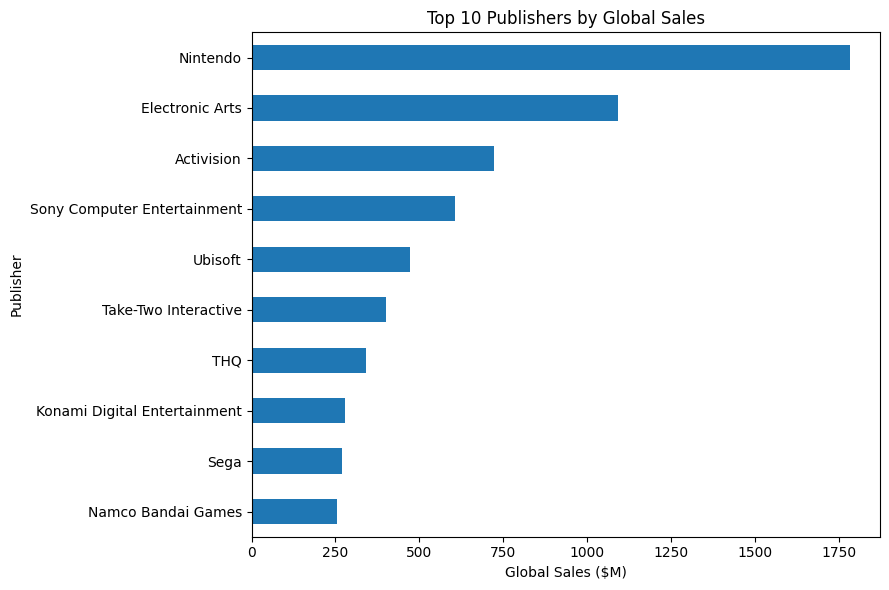

In [17]:
plt.figure(figsize=(9, 6))
top10_publisher.sort_values().plot(kind='barh', color='#1f77b4')
plt.xlabel('Global Sales ($M)')
plt.title('Top 10 Publishers by Global Sales')
plt.tight_layout()
plt.show()

In [18]:
region_totals = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].sum()
region_share = (region_totals / region_totals['Global_Sales'] * 100).round(2)
print("Umumi bazar payi (%):")
print(region_share)

Umumi bazar payi (%):
NA_Sales         49.13
EU_Sales         27.31
JP_Sales         14.56
Other_Sales       8.95
Global_Sales    100.00
dtype: float64


In [19]:
genre_region = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Global_Sales']].sum()
for col in ['NA_Sales', 'EU_Sales', 'JP_Sales']:
    genre_region[f'{col}_pct'] = (genre_region[col] / genre_region['Global_Sales'] * 100).round(1)

genre_region_pct = genre_region[['NA_Sales_pct', 'EU_Sales_pct', 'JP_Sales_pct']].sort_values('NA_Sales_pct', ascending=False)
print(genre_region_pct)

              NA_Sales_pct  EU_Sales_pct  JP_Sales_pct
Genre                                                 
Shooter               56.0          30.3           3.7
Platform              53.8          24.2          15.8
Sports                51.2          28.4          10.3
Misc                  50.5          26.8          13.4
Puzzle                50.4          20.9          23.4
Action                50.0          30.0           9.2
Fighting              49.7          22.5          19.6
Racing                49.1          32.5           7.8
Simulation            46.6          29.0          16.3
Adventure             43.5          27.2          22.2
Strategy              39.1          25.9          28.3
Role-Playing          35.3          20.3          37.9


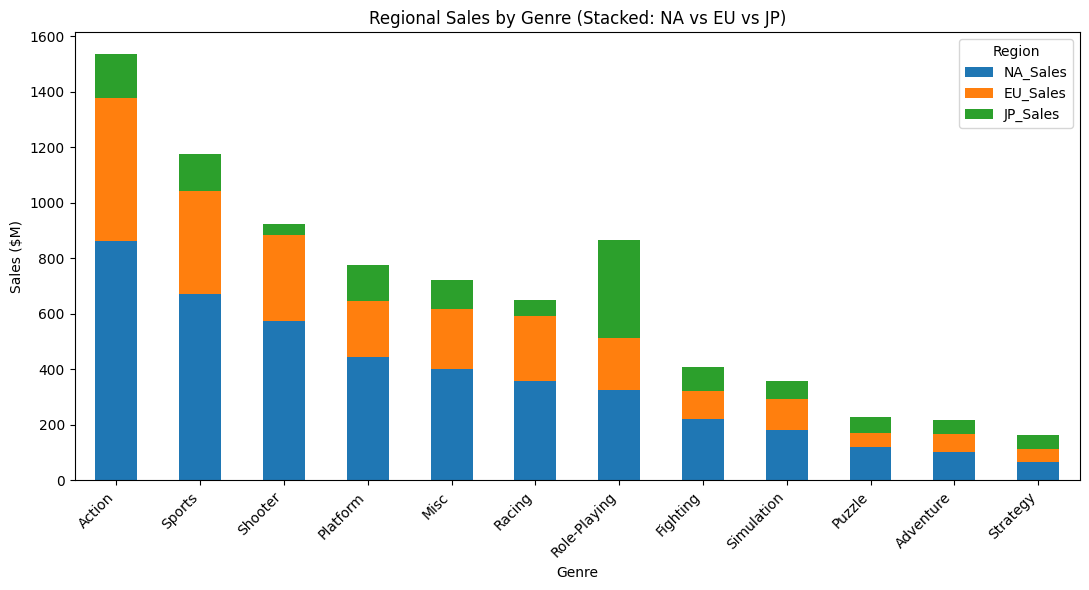

In [20]:
genre_region_abs = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales']].sum().sort_values('NA_Sales', ascending=False)
genre_region_abs.plot(kind='bar', stacked=True, figsize=(11, 6),
                       color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylabel('Sales ($M)')
plt.title('Regional Sales by Genre (Stacked: NA vs EU vs JP)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Region')
plt.tight_layout()
plt.show()

In [21]:
for region_col, region_name in [('NA_Sales', 'North America'), ('EU_Sales', 'Europe'), ('JP_Sales', 'Japan')]:
    top_genre = df.groupby('Genre')[region_col].sum().sort_values(ascending=False)
    print(f"{region_name}: en populyar janr = {top_genre.index[0]} ({top_genre.iloc[0]:.1f}M)")
    print(top_genre.head(3).to_string())
    print()

North America: en populyar janr = Action (861.8M)
Genre
Action     861.80
Sports     670.09
Shooter    575.16

Europe: en populyar janr = Action (516.5M)
Genre
Action     516.48
Sports     371.34
Shooter    310.45

Japan: en populyar janr = Role-Playing (350.3M)
Genre
Role-Playing    350.29
Action          158.66
Sports          134.76



In [22]:
df_trend = df[(df['Year'] >= 1980) & (df['Year'] <= 2016)]
yearly_sales = df_trend.groupby('Year')['Global_Sales'].sum()
print("Pik il:", yearly_sales.idxmax(), f"({yearly_sales.max():.1f}M)")
print(yearly_sales)

Pik il: 2008 (678.9M)
Year
1980     11.38
1981     35.77
1982     28.86
1983     16.79
1984     50.36
1985     53.94
1986     37.07
1987     21.74
1988     47.22
1989     73.45
1990     49.39
1991     32.23
1992     76.16
1993     45.98
1994     79.17
1995     88.11
1996    199.15
1997    200.98
1998    256.47
1999    251.27
2000    201.56
2001    331.47
2002    395.52
2003    357.85
2004    419.31
2005    459.94
2006    521.04
2007    611.13
2008    678.90
2009    667.30
2010    600.45
2011    515.99
2012    363.54
2013    368.11
2014    337.05
2015    264.44
2016     70.93
Name: Global_Sales, dtype: float64


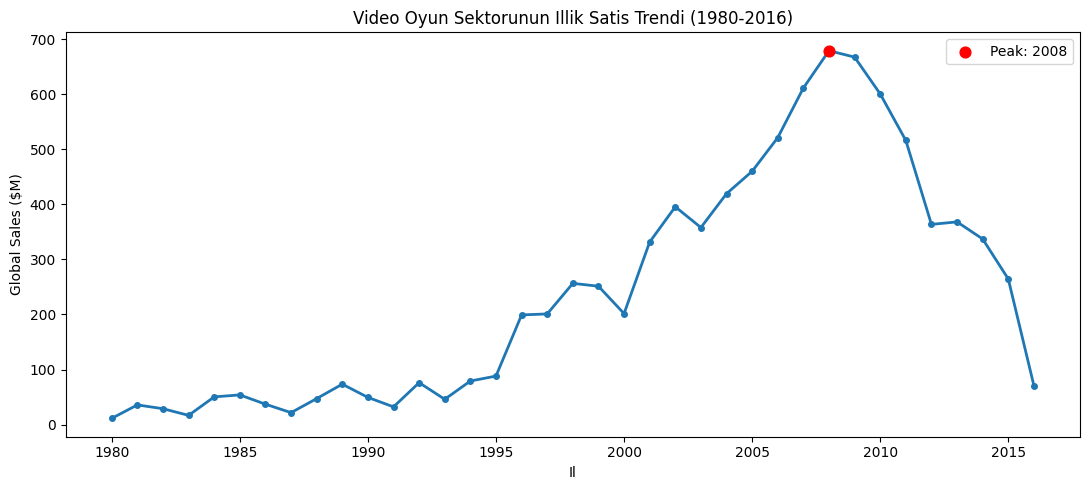

In [23]:
plt.figure(figsize=(11, 5))
plt.plot(yearly_sales.index, yearly_sales.values, marker='o', linewidth=2, color='#1f77b4', markersize=4)
peak_year = yearly_sales.idxmax()
plt.scatter([peak_year], [yearly_sales.max()], color='red', zorder=5, s=60, label=f'Peak: {peak_year}')
plt.xlabel('Il')
plt.ylabel('Global Sales ($M)')
plt.title('Video Oyun Sektorunun Illik Satis Trendi (1980-2016)')
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
top10_games = df.nlargest(10, 'Global_Sales')[['Name', 'Platform', 'Genre', 'Publisher', 'Year', 'Global_Sales']]
print(top10_games.to_string(index=False))

                     Name Platform        Genre Publisher  Year  Global_Sales
               Wii Sports      Wii       Sports  Nintendo  2006         82.74
        Super Mario Bros.      NES     Platform  Nintendo  1985         40.24
           Mario Kart Wii      Wii       Racing  Nintendo  2008         35.82
        Wii Sports Resort      Wii       Sports  Nintendo  2009         33.00
 Pokemon Red/Pokemon Blue       GB Role-Playing  Nintendo  1996         31.37
                   Tetris       GB       Puzzle  Nintendo  1989         30.26
    New Super Mario Bros.       DS     Platform  Nintendo  2006         30.01
                 Wii Play      Wii         Misc  Nintendo  2006         29.02
New Super Mario Bros. Wii      Wii     Platform  Nintendo  2009         28.62
                Duck Hunt      NES      Shooter  Nintendo  1984         28.31


In [25]:
def get_decade(year):
    if 1980 <= year < 1990:
        return '80s'
    elif 1990 <= year < 2000:
        return '90s'
    elif 2000 <= year < 2010:
        return '2000s'
    elif 2010 <= year <= 2020:
        return '2010s'
    return 'Other'

df['Decade'] = df['Year'].apply(get_decade)
decade_avg = df[df['Decade'] != 'Other'].groupby('Decade')['Global_Sales'].mean().reindex(['80s', '90s', '2000s', '2010s'])
print("Onilliy uzre orta satis (oyun basina, $M):")
print(decade_avg.round(3))
print(f"\nEn yuksek orta satis: {decade_avg.idxmax()} ({decade_avg.max():.3f}M/oyun)")

Onilliy uzre orta satis (oyun basina, $M):
Decade
80s      1.837
90s      0.723
2000s    0.504
2010s    0.490
Name: Global_Sales, dtype: float64

En yuksek orta satis: 80s (1.837M/oyun)


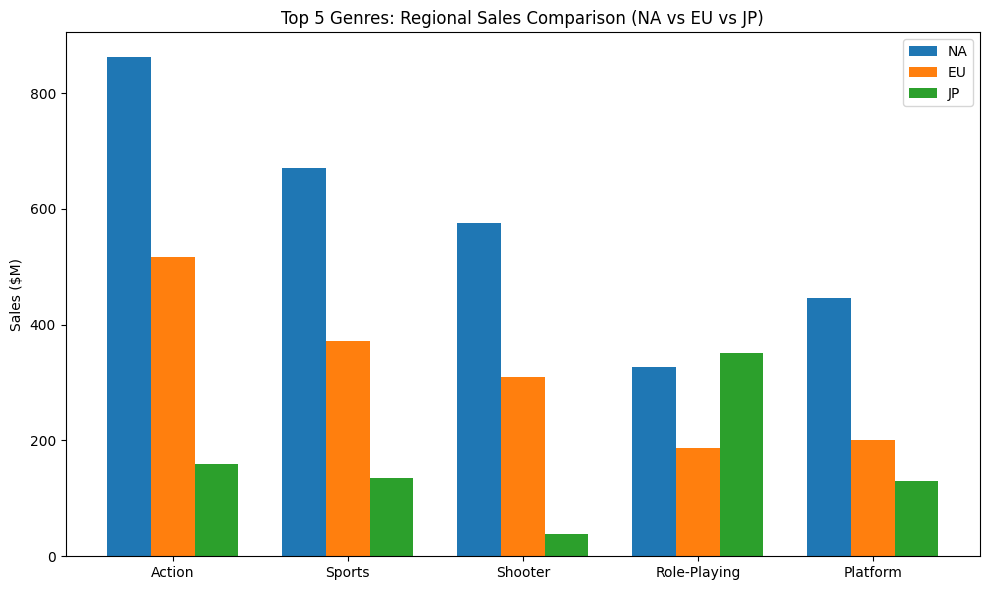

In [27]:
top5_genres = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False).head(5).index
top5_region = df[df['Genre'].isin(top5_genres)].groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales']].sum()
top5_region = top5_region.loc[top5_genres]
x = np.arange(len(top5_region))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, top5_region['NA_Sales'], width, label='NA', color='#1f77b4')
plt.bar(x, top5_region['EU_Sales'], width, label='EU', color='#ff7f0e')
plt.bar(x + width, top5_region['JP_Sales'], width, label='JP', color='#2ca02c')
plt.xticks(x, top5_region.index)
plt.ylabel('Sales ($M)')
plt.title('Top 5 Genres: Regional Sales Comparison (NA vs EU vs JP)')
plt.legend()
plt.tight_layout()
plt.show()